In [3]:
!pip install -U scikit-fuzzy

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 KB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894088 sha256=5924d2f88bc6228fafb28f151a4f303ac7fddda4a5fb0c6366b29e318b89d0b1
  Stored in directory: /root/.cache/pip/wheels/2c/04/80/7eefb1a2de7d36aefd06432fab2a1486caf0a0596a7067391a
Successfully built scikit-fuzzy


## Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

data = pd.read_csv("Hasil_Tanaman_with_status - hasil_tanaman.csv")

## Himpunanan Suhu

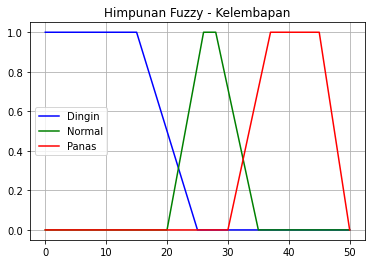

In [8]:
x_suhu = np.arange(0, 51, 1)
suhu = ctrl.Antecedent(x_suhu, "Suhu")

suhu_dingin = fuzz.trapmf(x_suhu, [0, 0, 15, 25])
suhu_normal = fuzz.trapmf(x_suhu, [20, 26, 28, 35])
suhu_panas = fuzz.trapmf(x_suhu, [30, 37, 45, 50])

suhu['Dingin'] = fuzz.trapmf(suhu.universe, [0, 0, 15, 25])
suhu['Normal'] = fuzz.trapmf(suhu.universe, [20, 26, 28, 35])
suhu['Panas'] = fuzz.trapmf(suhu.universe, [30, 37, 45, 50])

plt.plot(x_suhu, suhu_dingin, 'b', linewidth=1.5, label='Dingin')
plt.plot(x_suhu, suhu_normal, 'g', linewidth=1.5, label='Normal')
plt.plot(x_suhu, suhu_panas, 'r', linewidth=1.5, label='Panas')
plt.title('Himpunan Fuzzy - Kelembapan')
plt.legend()
plt.grid()
plt.savefig("himpunan Kelembapan.jpg",dpi=300)
plt.show()

## Himpunan Kelembapan

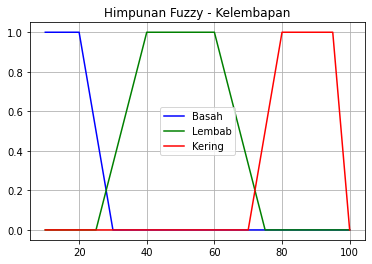

In [9]:
x_kelembapan = np.arange(10, 101, 1)
kelembapan = ctrl.Antecedent(x_kelembapan, "Kelembapan")

kelembapan_basah = fuzz.trapmf(x_kelembapan, [10, 10, 20, 30])
kelembapan_lembab = fuzz.trapmf(x_kelembapan, [25, 40, 60, 75])
kelembapan_kering = fuzz.trapmf(x_kelembapan, [70, 80, 95, 100])

kelembapan['Basah'] = fuzz.trapmf(kelembapan.universe,  [10, 10, 20, 30])
kelembapan['Lembab'] = fuzz.trapmf(kelembapan.universe, [25, 40, 60, 75])
kelembapan['Kering'] = fuzz.trapmf(kelembapan.universe, [70, 80, 95, 100])

plt.plot(x_kelembapan, kelembapan_basah, 'b', linewidth=1.5, label='Basah')
plt.plot(x_kelembapan, kelembapan_lembab, 'g', linewidth=1.5, label='Lembab')
plt.plot(x_kelembapan, kelembapan_kering, 'r', linewidth=1.5, label='Kering')
plt.title('Himpunan Fuzzy - Kelembapan')
plt.legend()
plt.grid()
plt.savefig("himpunan Kelembapan.jpg",dpi=300)
plt.show()

## Himpunan Cahaya

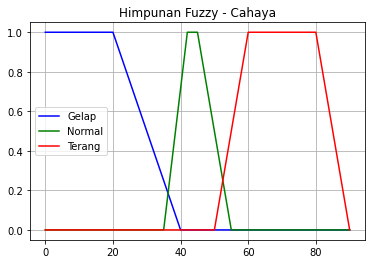

In [10]:
x_cahaya = np.arange(0, 91, 1)
cahaya = ctrl.Antecedent(x_cahaya, "Cahaya")

cahaya_gelap = fuzz.trapmf(x_cahaya, [0, 0, 20, 40])
cahaya_normal = fuzz.trapmf(x_cahaya, [35, 42, 45, 55])
cahaya_terang = fuzz.trapmf(x_cahaya, [50, 60, 80, 90])

cahaya['Gelap'] = fuzz.trapmf(cahaya.universe, [0, 0, 20, 40])
cahaya['Normal'] = fuzz.trapmf(cahaya.universe, [35, 42, 45, 55])
cahaya['Terang'] = fuzz.trapmf(cahaya.universe, [50, 60, 80, 90])

plt.plot(x_cahaya, cahaya_gelap, 'b', linewidth=1.5, label='Gelap')
plt.plot(x_cahaya, cahaya_normal, 'g', linewidth=1.5, label='Normal')
plt.plot(x_cahaya, cahaya_terang, 'r', linewidth=1.5, label='Terang')
plt.title('Himpunan Fuzzy - Cahaya')
plt.legend()
plt.grid()
plt.savefig("himpunan cahaya.jpg",dpi=300)
plt.show()


Output Kualitas Tanah:  49.999999999999986


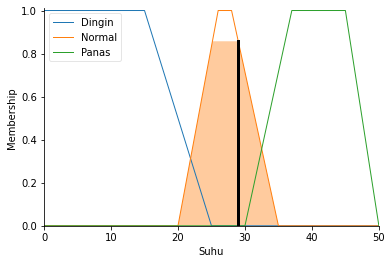

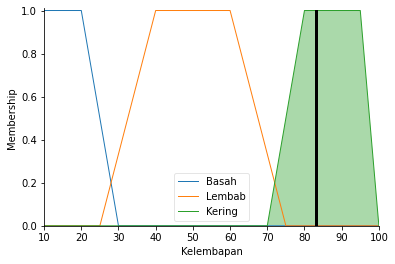

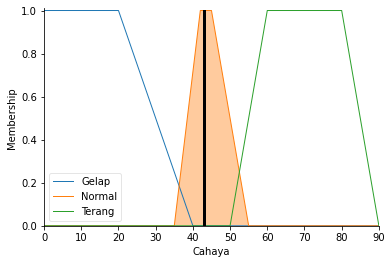

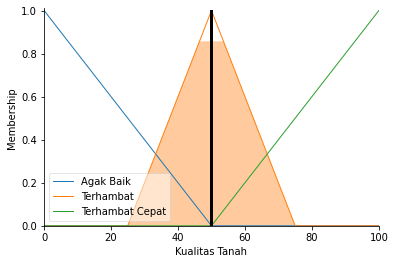

Hasil kualitas tanah: 50.00


In [12]:
# Membuat himpunan fuzzy untuk output (kesesuaian lahan)
kesesuaian = np.arange(0, 11, 1)
kesesuaian_buruk = fuzz.trimf(kesesuaian, [0, 0, 5])
kesesuaian_cukup = fuzz.trimf(kesesuaian, [0, 5, 10])
kesesuaian_baik = fuzz.trimf(kesesuaian, [5, 10, 10])

# Menentukan fungsi keanggotaan untuk variabel output
# Membuat Variabel Output
kualitas_tanah = ctrl.Consequent(np.arange(0, 101, 1), 'Kualitas Tanah')
kualitas_tanah['Agak Baik'] = fuzz.trimf(kualitas_tanah.universe, [0, 0, 50])
kualitas_tanah['Terhambat'] = fuzz.trimf(kualitas_tanah.universe, [25, 50, 75])
kualitas_tanah['Terhambat Cepat'] = fuzz.trimf(kualitas_tanah.universe, [50, 100, 100])

# Menentukan aturan fuzzy & menggunakan fungsi implikasi 
rule1 = ctrl.Rule(suhu['Dingin'] & kelembapan['Lembab'] & cahaya['Normal'], kualitas_tanah['Agak Baik'])
rule2 = ctrl.Rule(suhu['Normal'] & kelembapan['Lembab'] & cahaya['Normal'], kualitas_tanah['Agak Baik'])
rule3 = ctrl.Rule(suhu['Dingin'] & kelembapan['Kering'] & cahaya['Gelap'], kualitas_tanah['Terhambat'])
rule4 = ctrl.Rule(suhu['Normal'] & kelembapan['Kering'] & cahaya['Normal'], kualitas_tanah['Terhambat'])
rule5 = ctrl.Rule(suhu['Panas'] & kelembapan['Kering'] & cahaya['Normal'], kualitas_tanah['Terhambat'])
rule6 = ctrl.Rule(suhu['Panas'] & kelembapan['Lembab'] & cahaya['Terang'], kualitas_tanah['Terhambat'])
rule7 = ctrl.Rule(suhu['Panas'] & kelembapan['Kering'] & cahaya['Terang'], kualitas_tanah['Terhambat Cepat'])
rule8 = ctrl.Rule(suhu['Dingin'] & kelembapan['Lembab'] & cahaya['Gelap'], kualitas_tanah['Terhambat Cepat'])
rule9 = ctrl.Rule(suhu['Dingin'] & kelembapan['Basah'] & cahaya['Gelap'], kualitas_tanah['Terhambat Cepat'])

#Aplikasi fungsi implikasi
kualitas_tanah_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
kualitas_tanah_prediksi = ctrl.ControlSystemSimulation(kualitas_tanah_ctrl)

#Menginputkan nilai variabel input
kualitas_tanah_prediksi.input['Suhu'] = 29
kualitas_tanah_prediksi.input['Kelembapan'] = 83
kualitas_tanah_prediksi.input['Cahaya'] = 43

#Menghitung hasil akhir
kualitas_tanah_prediksi.compute()

#Menampilkan hasil akhir
print("Output Kualitas Tanah: ", kualitas_tanah_prediksi.output['Kualitas Tanah'])

#Plot hasil akhir
suhu.view(sim=kualitas_tanah_prediksi)
plt.savefig("output suhu.jpg",dpi=300)

kelembapan.view(sim=kualitas_tanah_prediksi)
plt.savefig("output kelembapan.jpg",dpi=300)

cahaya.view(sim=kualitas_tanah_prediksi)
plt.savefig("output cahaya.jpg",dpi=300)

kualitas_tanah.view(sim=kualitas_tanah_prediksi)
plt.savefig("output kualitas tanah.jpg",dpi=300)

plt.show()

#Menghitung defuzzifikasi dengan metode centroid
kualitas_tanah_prediksi.compute()
hasil = kualitas_tanah_prediksi.output['Kualitas Tanah']

#Menampilkan hasil defuzzifikasi
print("Hasil kualitas tanah: {:.2f}".format(hasil))